Note: To run these simulations you need to install DIPY and DISIMPY (note to run disimpy you need gpus)

In [ ]:
# Import the required packages and modules

import os
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from scipy.io import savemat

import dipy.reconst.dki as dki
from dipy.core.gradients import gradient_table
from dipy.core.sphere import disperse_charges, HemiSphere

from disimpy import gradients, simulations, substrates, utils

# Define the parameters for the substrate simulation

Note: to produce all simulations in folder "MC_results_from_step001" you need to run this code for different AS values [0 to 0.6] for bout intra=false and intra = true.

In [ ]:
intra = False

r0 = 1e-6
axon_l = (1.5e-6 + 4*r0)

print(r0)
print(axon_l)
B = 2 * np.pi/axon_l

As = np.array(0.3)

vf = 0.7
extra_diff = 1.5
intra_diff = 2.5

print(vf)

1e-06
5.5e-06
0.7


### Generate axons

We have a simple mathematical model for a beading axon aligned with the $z$-axis. The radius is

$$
r(z) = r_0 \left[1 + A \sin(Bz) \right] ,
$$

where $r_0$ is the mean radius, $A \in [0,1]$ is controls the amplitude of beading, and $B$ controls the frequency and location of beading. The volume is given by

$$
V = \int_0^l \pi r(z)^2 dz ,
$$

where $l$ is the length of the axon.

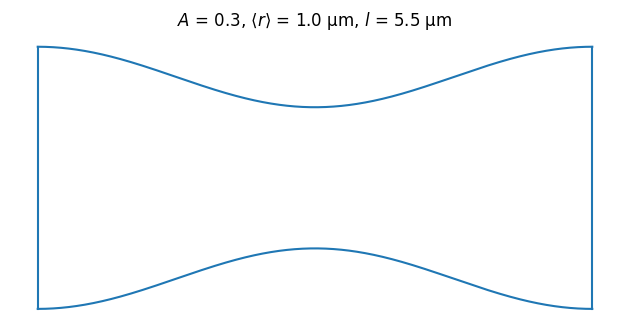

In [ ]:
# Fist check on the geometry that we want to simulate

B = 2 * np.pi / axon_l

rs = np.ones(As.shape) * r0  # For constant surface
#rs = _calc_rs(As, 1e-6)     # For constant volume

shift = False
if shift:
    z = np.linspace(-0.5, 0.5, 1000) * axon_l
else:
    z = np.linspace(0, 1, 1000) * axon_l
l = max(z) - min(z)
if np.shape(As) == ():
    A = As
    r = rs
    i = 0
    fig, ax = plt.subplots(1)
    ax.plot(z,
            r*(1 + A*np.cos(B*z)),
            color='tab:blue')
    ax.plot(z,
            -r*(1 + A*np.cos(B*z)),
            color='tab:blue')
    ax.plot([z[0], z[0]],
            [-r*(1 + A*np.cos(B*z[0])), r*(1+ A*np.cos(B*z[0]))],
            color='tab:blue')
    ax.plot([z[-1], z[-1]],
            [-r*(1 + A*np.cos(B*z[0])), r*(1+ A*np.cos(B*z[0]))],
            color='tab:blue')
    ax.set_title(r'$A$ = %s, $\langle r \rangle$ = %s μm, $l$ = %s μm'
                 % (np.round(A, 2),
                    np.round(r * 1e6, 2),
                    np.round(l * 1e6, 1)))
    ax.set_aspect('equal')
    ax.axis('off')
    fig.tight_layout()
    plt.show()
    fig.savefig('fibre_%s_crossection.pdf' % (i + 1), dpi=500)
else:
    for i, (A, r) in enumerate(zip(As, rs)):
        fig, ax = plt.subplots(1)
        ax.plot(z,
                r*(1 + A*np.cos(B*z)),
                color='tab:blue')
        ax.plot(z,
                -r*(1 + A*np.cos(B*z)),
                color='tab:blue')
        ax.plot([z[0], z[0]],
                [-r*(1 + A*np.cos(B*z[0])), r*(1+ A*np.cos(B*z[0]))],
                color='tab:blue')
        ax.plot([z[-1], z[-1]],
                [-r*(1 + A*np.cos(B*z[0])), r*(1+ A*np.cos(B*z[0]))],
                color='tab:blue')
        ax.set_title(r'$A$ = %s, $\langle r \rangle$ = %s μm, $l$ = %s μm'
                     % (np.round(A, 2),
                        np.round(r * 1e6, 2),
                        np.round(l * 1e6, 1)))
        ax.set_aspect('equal')
        ax.axis('off')
        fig.tight_layout()
        plt.show()
        fig.savefig('fibre_%s_crossection.pdf' % (i + 1), dpi=500)

In [ ]:
# Define the required functions for building the actual simulations

def create_end_cap(edge_points, z_val, is_base=True):
    """
    Create a triangular cap by connecting all edge points to a center point (0, 0, z_val).
    If is_base=True, triangle normals will point outward.
    """
    center = np.array([0.0, 0.0, z_val])
    cap_triangles = []
    N = edge_points.shape[0]

    for i in range(N):
        i_next = (i + 1) % N
        tri = [edge_points[i], edge_points[i_next], center]
        if not is_base:
            tri = tri[::-1]  # reverse for correct normal
        cap_triangles.append(tri)
    return np.array(cap_triangles)


def generate_axon(A, r, axon_l, N_segments, N_xy, B=2 * np.pi, phi=0.0,
                  cap_ends=True, cut=False):
    """
    Generate a beaded axon mesh with optional end caps and optional longitudinal cuts
    along y=0 or x=0 planes, and their respective caps.
    Only supports cuts in the positive direction (y > 0 or x > 0).
    """

    h = axon_l / N_segments
    z_vals = np.linspace(0, axon_l, N_segments)
    beading = A * r * np.sin(B * z_vals + phi)
    rsamp = r + beading

    # Sample theta
    thetas = np.linspace(0, 2 * np.pi, N_xy, endpoint=False)
    rings = []

    for z, radius in zip(z_vals, rsamp):
        ring = np.array([[np.cos(theta) * radius, np.sin(theta) * radius, z] for theta in thetas])
        rings.append(ring)

    triangles = []

    # Connect rings to form the side mesh
    for i in range(N_segments - 1):
        ring0 = rings[i]
        ring1 = rings[i + 1]
        for j in range(N_xy):
            jp = (j + 1) % N_xy
            tri1 = [ring0[j], ring1[j], ring0[jp]]
            tri2 = [ring0[jp], ring1[j], ring1[jp]]
            triangles.extend([tri1, tri2])

    # Add end caps
    if cap_ends:
        triangles.extend(create_end_cap(rings[0], z_vals[0], is_base=True))
        triangles.extend(create_end_cap(rings[-1], z_vals[-1], is_base=False))


    if cut:
        # Apply y > 0 cut
        triangles = [tri for tri in triangles if all(pt[1] >= 0 for pt in tri)]

        cap_triangles = []
        for i in range(N_segments - 1):
            z0, z1 = z_vals[i], z_vals[i + 1]
            r0, r1 = rsamp[i], rsamp[i + 1]

            # Right side (x > 0)
            pt0 = [r0, 0, z0]
            pt1 = [r1, 0, z1]
            center0 = [0, 0, z0]
            center1 = [0, 0, z1]

            cap_triangles.append([pt0, pt1, center0])
            cap_triangles.append([pt1, center1, center0])

            # Left side (x < 0)
            #pt2 = [-r0, 0, z0]
            #pt3 = [-r1, 0, z1]
            #cap_triangles.append([pt3, pt2, center0])
            #cap_triangles.append([pt3, center0, center1])

        triangles.extend(cap_triangles)

        # Apply x > 0 cut
        triangles = [tri for tri in triangles if all(pt[0] >= 0 for pt in tri)]

        cap_triangles = []
        for i in range(N_segments - 1):
            ring0 = rings[i]
            ring1 = rings[i + 1]

            # For each pair of points along x=0 with y > 0
            for j in range(N_xy):
                pt0 = ring0[j]
                pt1 = ring1[j]
                if np.isclose(pt0[0], 0.0, atol=1e-12) and np.isclose(pt1[0], 0.0, atol=1e-12) and pt0[1] > 0:
                    center0 = [0, 0, pt0[2]]
                    center1 = [0, 0, pt1[2]]
                    cap_triangles.append([pt0, pt1, center0])
                    cap_triangles.append([pt1, center1, center0])

        triangles.extend(cap_triangles)

    return np.array(triangles)


# Extra-cellular unit

In [ ]:
def mirror_mesh(mesh, flip_x=False, flip_y=False):
    """
    Mirror the mesh across x=0 and/or y=0 planes.

    Parameters:
    - mesh: numpy array of shape (N_triangles, 3, 3)
    - flip_x: if True, inverts the x-coordinates (mirrors over y-z plane)
    - flip_y: if True, inverts the y-coordinates (mirrors over x-z plane)

    Returns:
    - mirrored_mesh: numpy array of the same shape as mesh
    """
    mirrored_mesh = mesh.copy()
    if flip_x:
        mirrored_mesh[:, :, 0] *= -1  # Flip x-axis
    if flip_y:
        mirrored_mesh[:, :, 1] *= -1  # Flip y-axis
    return mirrored_mesh


def generate_extra(A, r, axon_l, N_segments, N_xy, B, f):
    """Generate the final mesh from truncated cones."""

    #rs = _calc_rs(A, r0)
    rs = r
    r0 = r

    # axon types
    axon0 = generate_axon(A, r, axon_l, N_segments, N_xy, B=B,
                          phi=np.pi/2,
                          cap_ends=False, cut=False)
    axon1 = generate_axon(A, r, axon_l, N_segments, N_xy, B=B,
                          phi=-np.pi/2,
                          cap_ends=False, cut=True)

    # shifts to positioning axons
    #c = np.sqrt(2*np.pi/vf) - 4*np.sqrt(2/3)
    #shift = (4*np.sqrt(2/3) + c) * r0
    c =  np.sqrt(2*np.pi*(0.5*A**2+1)/f) - 2*np.sqrt(2)
    shift = np.sqrt(2*np.pi*(0.5*A**2+1)/f) * r0

    print(shift)

    # 4 corner axons based on quadrants of axon1
    shape0 = axon1.shape
    shape1 = (shape0[0]*shape0[1], shape0[2])

    # Quadrant I
    axonq1 = axon1.copy()

    # Quadrant II
    axonq2 = mirror_mesh(axon1.copy(), flip_x=True)

    # Quadrant III
    axonq3 = mirror_mesh(axon1.copy(), flip_x=True, flip_y=True)

    # Quadrant IV
    axonq4 = mirror_mesh(axon1.copy(), flip_y=True)

    #axonq1 = axonq1.reshape(shape0)
    #axonq2 = axonq2.reshape(shape0)
    #axonq3 = axonq3.reshape(shape0)
    #axonq4 = axonq4.reshape(shape0)

    # Add shifts and concatenate axons
    mesh = []
    #mesh.append(axonq1)
    axonq2[:, :, 0] = axonq2[:, :, 0] + shift
    mesh = np.concatenate((axonq1, axonq2), axis=0)
    axonq3[:, :, :2] = axonq3[:, :, :2] + shift
    mesh = np.concatenate((mesh, axonq3), axis=0)
    axonq4[:, :, 1] = axonq4[:, :, 1] + shift
    mesh = np.concatenate((mesh, axonq4), axis=0)

    # Add central axon based on axon 2
    axon0[:, :, :2] = axon0[:, :, :2] + shift/2
    mesh = np.concatenate((mesh, axon0), axis=0)

    return mesh

In [ ]:
N_segments = 10
N_xy = 32

In [ ]:
h = axon_l / N_segments

In [ ]:
print(h)
print(r)

5.5e-07
1e-06


In [ ]:
# Create the axon meshes
#As = np.linspace(0.1, .6, 6)
if intra:
    #rs = _calc_rs(As, 1e-6)
    A = As
    axons = generate_axon(A, r, axon_l, N_segments, N_xy, B=B,
                          phi=np.pi/2, cap_ends=False, cut=False)
else:
    #rs = _calc_rs(As, 1e-6)
    A = As
    f = vf
    axons = generate_extra(A, r, axon_l, N_segments, N_xy, B, f)

3.0626619248160733e-06


In [ ]:
def plot_mesh(triangles, color='skyblue', alpha=0.8, elev=30, azim=45):
    """Visualize the 3D mesh using matplotlib."""
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')

    mesh = Poly3DCollection(triangles, facecolor=color, edgecolor='k', linewidths=0.2, alpha=alpha)
    ax.add_collection3d(mesh)

    # Auto-scale axes
    all_pts = triangles.reshape(-1, 3)
    max_range = (all_pts.max(axis=0) - all_pts.min(axis=0)).max() / 2.0
    mid = all_pts.mean(axis=0)
    ax.set_xlim(mid[0] - max_range, mid[0] + max_range)
    ax.set_ylim(mid[1] - max_range, mid[1] + max_range)
    ax.set_zlim(mid[2] - max_range, mid[2] + max_range)

    ax.view_init(elev=elev, azim=azim)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Beading Axon Mesh')
    plt.tight_layout()

    plt.show()

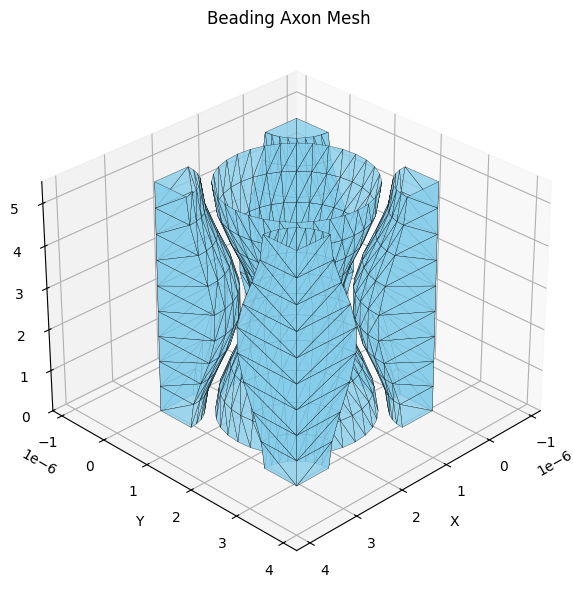

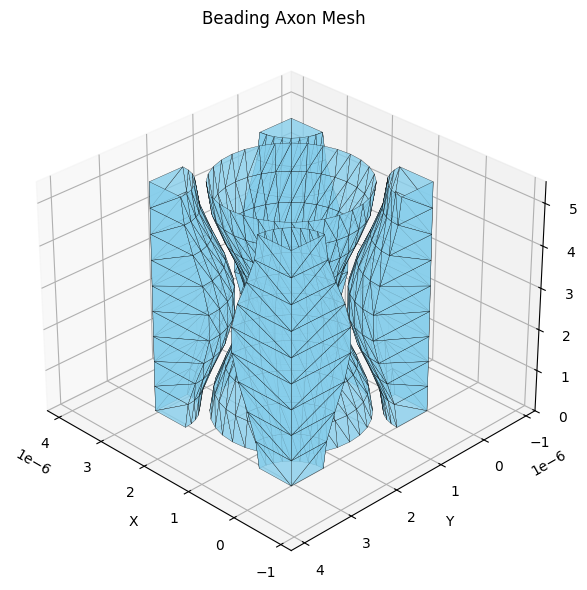

In [ ]:
plot_mesh(axons, azim=45, elev=30)
plot_mesh(axons, azim=135, elev=30)

### Define the acquisition protocol and run the simulations

/tmp/ipython-input-16-3807565754.py:12: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  dirs = np.loadtxt(get_fnames("t-design"))


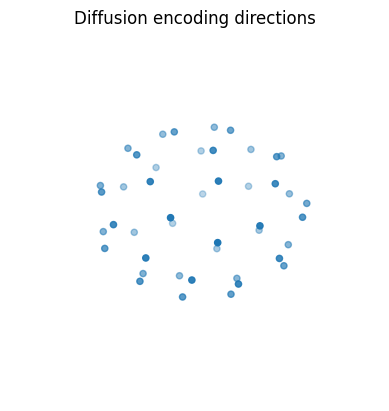

In [ ]:
# Reference directions

from dipy.data import get_fnames

n_dir = 45
dirs = np.loadtxt(get_fnames("t-design"))
dirs1 = dirs

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(dirs[:, 0], dirs[:, 1], dirs[:, 2])
plt.title('Diffusion encoding directions')
ax.axis('off')
plt.show()

In [ ]:
BigD = 10e-3
SmallD = 1.5e-3

t = BigD + SmallD
dt_ini = 1e-7

npoints = t/dt_ini
print(npoints)

115000.0


In [ ]:
SDp = round(SmallD/dt_ini)
BDp = round(BigD/dt_ini)
T = round(t/dt_ini)

115000


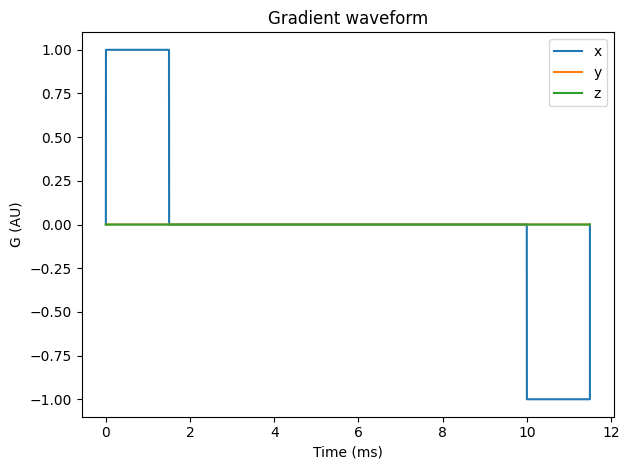

1.000008695727789e-07


In [ ]:
# Gradient waveform (Δ = 10 ms, δ = 1.5 ms), set 1

n_t = int(npoints)
print(n_t)

gradient = np.zeros((1, T+1, 3))
gradient[0, 1:SDp, 0] = 1
gradient[0, (BDp+1):(BDp+SDp), 0] = -1
gradient, dt = gradients.interpolate_gradient(gradient, dt_ini, n_t)

fig, ax = plt.subplots(1)
ax.plot(np.linspace(0, t * 1e3, gradient.shape[1]), gradient[0])
ax.legend(['x', 'y', 'z'])
ax.set_title('Gradient waveform')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('G (AU)')
fig.tight_layout()
plt.show()
fig.savefig('waveform.pdf', dpi=400)

print(dt)

In [ ]:
shift = np.sqrt(2*np.pi*(0.5*As**2+1)/vf) * r0
min_d1 = shift * np.sqrt(2) - rs * 4
min_d2 = shift - rs * 2
min_r = np.min(r*(1-As))
print('C1) Minimum size. Step length and grid as to be lower than {}'.format(np.min([min_d1, min_d2])))
print('C2) Minimum size. Step length and grid as to be lower than {}'.format(min_r))

# grid_sampling
Ns = 400
if intra:
    D0 = intra_diff*1e-9
else:
    D0 = extra_diff*1e-9

print('Grid length is {}'.format(shift/Ns))
print('Step length is {}'.format(np.sqrt(6*D0*dt)))

print('')
if np.min([min_d1, min_d2]) < np.max(shift/Ns):
    print('Increase Ns for minimal distance')

if min_r < np.max(shift/Ns):
    print('Increase Ns for minimal size')

if np.min([min_d1, min_d2]) < np.sqrt(6*D0*dt):
    print('Decrease dt for minimal distance')

if min_r < np.sqrt(6*D0*dt):
    print('Decrease dt for minimal size')


C1) Minimum size. Step length and grid as to be lower than 4.03193688921049e-07
C2) Minimum size. Step length and grid as to be lower than 6e-07
Grid length is 7.783820290784706e-09
Step length is 3.000013043563328e-08



In [ ]:
D0

1.5000000000000002e-09

[2.50e+08 5.00e+08 7.50e+08 1.00e+09 1.25e+09 1.50e+09 1.75e+09 2.00e+09]


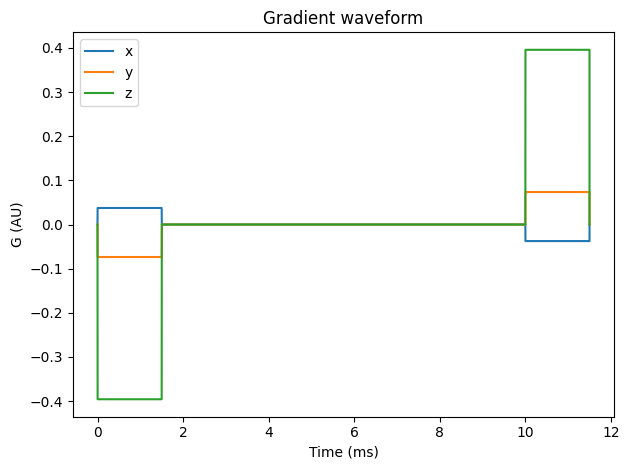

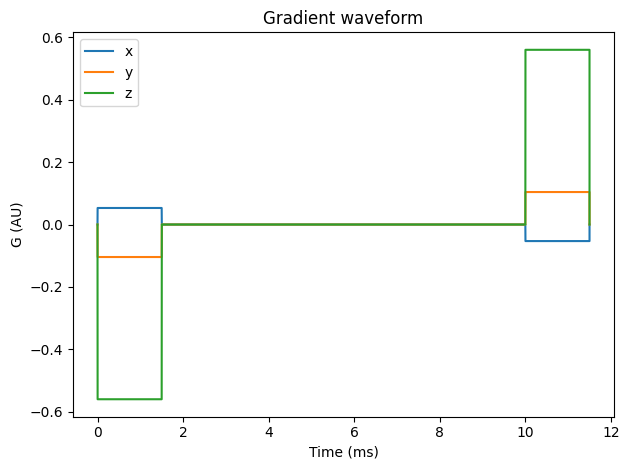

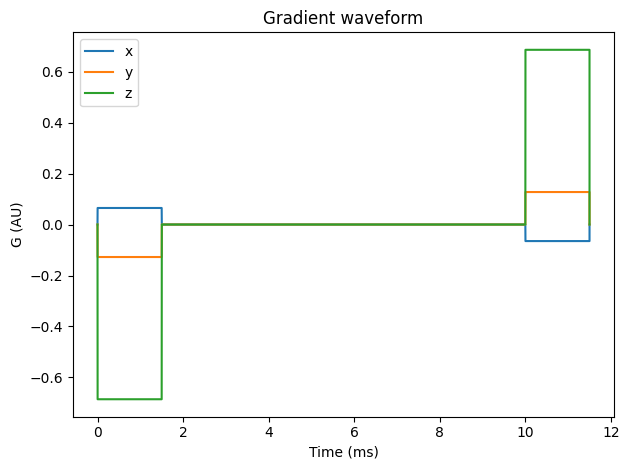

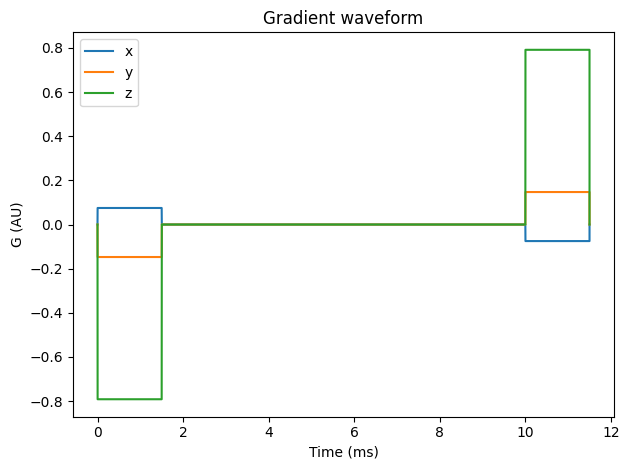

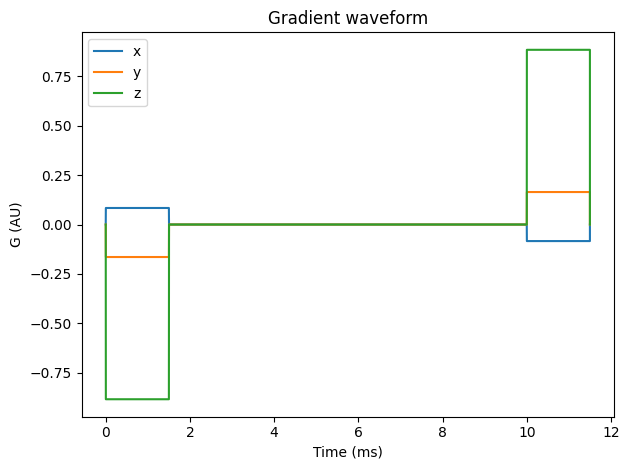

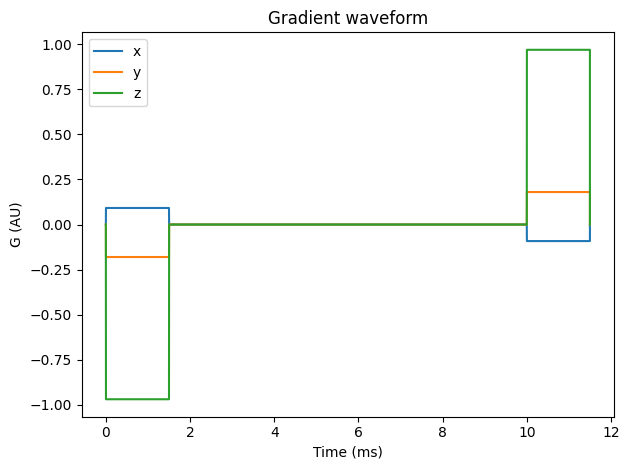

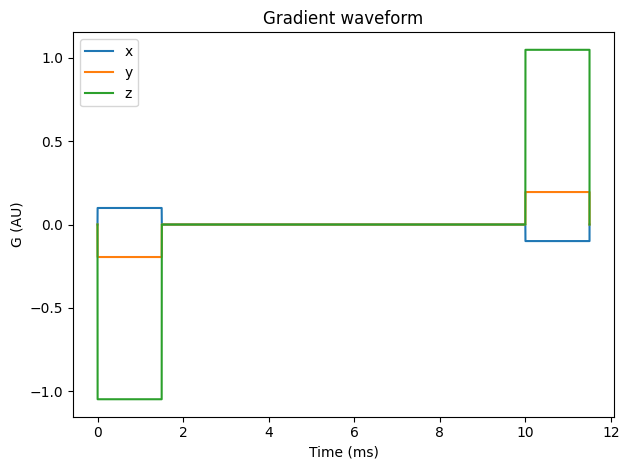

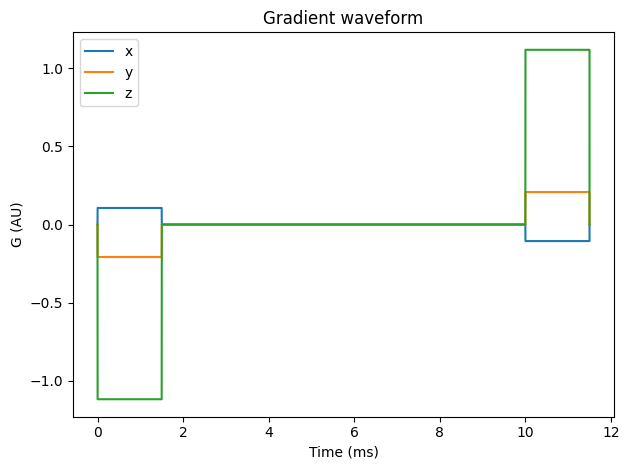

In [ ]:
# Define the simulated gradient array
b1_vec = np.array([0.25e9, 0.5e9, 0.75e9, 1e9,
                   1.25e9,  1.5e9,  1.75e9,
                   2e9])

btotal = np.array(b1_vec) 
print(btotal)

nb = b1_vec.shape[0]

bvals1 = np.empty((dirs1.shape[0]*nb,))
bvecs1 = np.empty((dirs1.shape[0]*nb, 3))
rb1 = np.empty((dirs1.shape[0]*nb,))


gradient_all = np.empty((dirs1.shape[0]*nb,) +  gradient.shape[1:])
for bi, bt in enumerate(btotal):
    for vi in range(dirs1.shape[0]):
        gradient = np.zeros((1, T+1, 3))

        v1 = dirs1[vi]
        gradient[0, 1:SDp, 0] = 1 * v1[0]
        gradient[0, (BDp+1):(BDp+SDp), 0] = -1 * v1[0]
        gradient[0, 1:SDp, 1] = 1 * v1[1]
        gradient[0, (BDp+1):(BDp+SDp), 1] = -1 * v1[1]
        gradient[0, 1:SDp, 2] = 1 * v1[2]
        gradient[0, (BDp+1):(BDp+SDp), 2] = -1 * v1[2]

        gradient, dt = gradients.interpolate_gradient(gradient, dt_ini, n_t)
        gradient = gradients.set_b(gradient, dt, bt)
        gradient_all[dirs1.shape[0]*bi+vi] = gradient
        bvals1[dirs1.shape[0]*bi+vi] = b1_vec[bi]
        #bvals2[dirs1.shape[0]*bi+vi] = b2_vec[bi]
        bvecs1[dirs1.shape[0]*bi+vi, :] = v1
        #bvecs2[dirs1.shape[0]*bi+vi, :] = v2

    fig, ax = plt.subplots(1)
    ax.plot(np.linspace(0, t * 1e3, gradient.shape[1]), gradient[0])
    ax.legend(['x', 'y', 'z'])
    ax.set_title('Gradient waveform')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('G (AU)')
    fig.tight_layout()
    plt.show()
    fig.savefig('shells.pdf', dpi=400)

# Run simulations

Check mesh convertion to face and vertices

In [ ]:
def mesh2vf(mesh):
    triangles = mesh.copy()
    vertices = np.unique(triangles.reshape(-1, 3), axis=0)

    for i, triangle in enumerate(triangles):
        face = np.zeros(3, dtype=int)
        for j, p in enumerate(triangle):
            idx_array = np.where((vertices == p).all(axis=1))[0]
            if idx_array.size != 1:
                raise ValueError(f"Vertex match not unique or missing for point {p}")
            face[j] = idx_array[0]
        if i == 0:
            faces = face[np.newaxis, :]
        else:
            faces = np.vstack((faces, face))
    return vertices, faces

In [ ]:
na

(1296, 3, 3)

Aligning the corner of the simulated voxel with the origin
Moved the vertices by [0. 0. 0.]
Dividing the mesh into subvoxels
Finished dividing the mesh into subvoxels


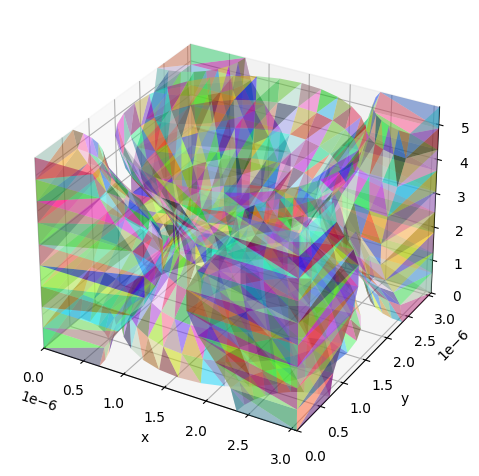

In [ ]:
#for i in range(na):
vertices, faces = mesh2vf(axons.astype(float))
substrate = substrates.mesh(vertices, faces, padding=np.zeros(3),
                            periodic=True, init_pos="extra")
utils.show_mesh(substrate)

In [ ]:
axons_v = []
axons_f = []
vertices, faces = mesh2vf(axons.astype(float))
axons_v.append(vertices)
axons_f.append(faces)
na = 1

Sanity check. Initial positions and trajectories.

In [ ]:
this_seed = 125

Aligning the corner of the simulated voxel with the origin
Moved the vertices by [0. 0. 0.]
Dividing the mesh into subvoxels
Finished dividing the mesh into subvoxels
Starting simulation
The trajectories file will be up to 0.00375 GB
Number of random walkers = 50
Number of steps = 1000
Step length = 3.000013043563328e-08 m
Step duration = 1.000008695727789e-07 s
Calculating initial positions
Finished calculating initial positions
Simulation finished


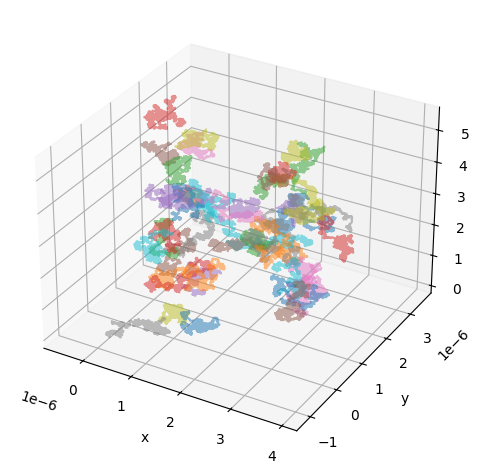

In [ ]:
n_s = int(50)
if intra:
    for i in range(na):
        diffusivity = intra_diff * 1e-9
        substrate = substrates.mesh(axons_v[i], axons_f[i], padding=np.zeros(3),
                                    periodic=True, init_pos="intra",
                                    n_sv=np.array([220, 220, 220]))
        signals = simulations.simulation(n_s, diffusivity, gradient[:, 0:1000, :], dt, substrate,
                                         seed=this_seed, traj='example_traj.txt')
        utils.show_traj('example_traj.txt')
else:
    for i in range(na):
        diffusivity = extra_diff * 1e-9
        substrate = substrates.mesh(axons_v[i], axons_f[i], padding=np.zeros(3),
                                    periodic=True, init_pos="extra",
                                    n_sv=np.array([380, 380, 380]))
        signals = simulations.simulation(n_s, diffusivity, gradient[:, 0:1000, :], dt, substrate,
                                         seed=this_seed, traj='example_traj.txt')
        utils.show_traj('example_traj.txt')

Save initial positions - spins after the time of the end of the first gradient
width

In [ ]:
n_s = int(1e5)
print(SDp)
print(SDp*dt)
if intra:
    diffusivity = intra_diff * 1e-9
    sig_pos = simulations.simulation(n_s, diffusivity,
                                     gradient_all[:, 0:SDp, :], dt,
                                     substrate, seed=this_seed,
                                     final_pos=True)

else:
    diffusivity = extra_diff * 1e-9
    sig_pos = simulations.simulation(n_s, diffusivity,
                                     gradient_all[:, 0:SDp, :], dt,
                                     substrate, seed=this_seed,
                                     final_pos=True)

15000
0.0015000130435916836
Starting simulation
Number of random walkers = 100000
Number of steps = 15000
Step length = 3.000013043563328e-08 m
Step duration = 1.000008695727789e-07 s
Calculating initial positions
Finished calculating initial positions
Simulation finished


In [ ]:
signals = sig_pos[0]
ini_pos = sig_pos[1]
print(np.shape(ini_pos))
print(np.shape(signals))

(100000, 3)
(360,)


/tmp/ipython-input-62-3503396648.py:3: RuntimeWarning: invalid value encountered in log
  ax.plot(np.log(signals / n_s))


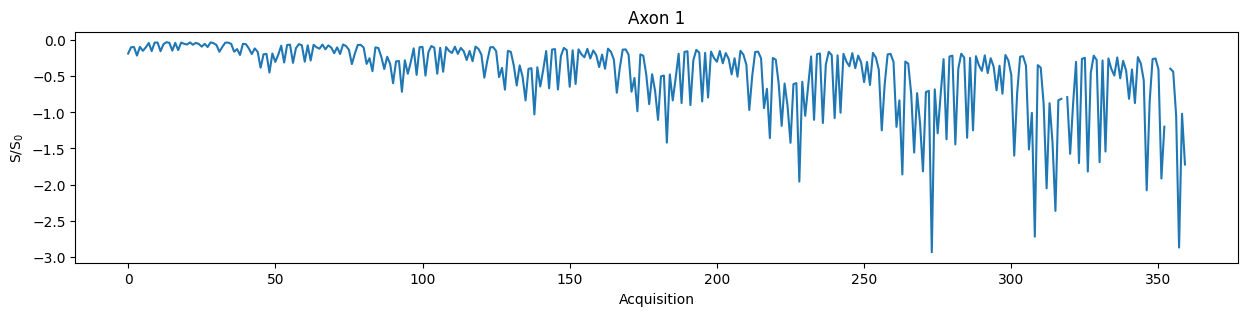

In [ ]:
# Show simulated signals
fig, ax = plt.subplots(1, na, figsize=(15, 3), sharey=True)
ax.plot(np.log(signals / n_s))
ax.set_title('Axon %s' % (i + 1))
ax.set_xlabel('Acquisition')
ax.set_ylabel('S/S$_0$')
sdecays = signals / n_s
plt.show()

if intra:
    np.savetxt('pos_intra_as{}_seed{}_intraD{}_0.txt'.format(int(As*100), this_seed, int(intra_diff*100)), ini_pos)
else:
    np.savetxt('pos_extra_as{}_seed{}_f{}_extraD{}_0.txt'.format(int(As*100), this_seed, int(vf*100), int(extra_diff*100)), ini_pos)

Save final positions - spins after the time of the end of the second gradient
width (time=BigD had passed between the end of first and second gradient width)

In [ ]:
n_s = int(1e5)
print(BDp+SDp)
print((BDp+SDp)*dt)
if intra:
    diffusivity = intra_diff * 1e-9
    sig_pos = simulations.simulation(n_s, diffusivity,
                                     gradient_all[:, 0:BDp+SDp, :], dt,
                                     substrate, seed=this_seed,
                                     final_pos=True)
else:
    diffusivity = extra_diff * 1e-9
    print(extra_diff)
    sig_pos = simulations.simulation(n_s, diffusivity,
                                     gradient_all[:, 0:BDp+SDp, :], dt,
                                     substrate, seed=this_seed,
                                     final_pos=True)

115000
0.011500100000869573
1.5
Starting simulation
Number of random walkers = 100000
Number of steps = 115000
Step length = 3.000013043563328e-08 m
Step duration = 1.000008695727789e-07 s
Calculating initial positions
Finished calculating initial positions
79.8%

In [ ]:
signals = sig_pos[0]
fin_pos = sig_pos[1]
print(np.shape(fin_pos))
print(np.shape(signals))

In [ ]:
# Show simulated signals
fig, ax = plt.subplots(1, na, figsize=(15, 3), sharey=True)
ax.plot(np.log(signals / n_s))
ax.set_title('Axon %s' % (i + 1))
ax.set_xlabel('Acquisition')
ax.set_ylabel('S/S$_0$')
sdecays = signals / n_s
plt.show()


if intra:
    np.savetxt('pos_intra_as{}_seed{}_intraD{}_1.txt'.format(int(As*100), this_seed, int(intra_diff*100)), fin_pos)
else:
    np.savetxt('pos_extra_as{}_seed{}_f{}_extraD{}_1.txt'.format(int(As*100), this_seed, int(vf*100), int(extra_diff*100)), fin_pos)
np.savetxt('bvals1.txt', bvals1)
np.savetxt('bvecs1.txt', bvecs1)